# Создание CNN для классификации изображений

Задание:  
1. Загрузить датасет CIFAR-10.  
2. Реализовать аугментацию (RandomCrop, Rotate, Flip).  
3. Обучить ResNet-18 (или другую CNN).  
4. Сравнить accuracy с аугментацией и без.  

Порядок выполнения:  
1. Загрузка данных и аугментация (torchvision.transforms).  
2. Определение модели (предобученная или с нуля).  
3. Обучение и валидация.  
4. Сравнение метрик.  

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [45]:
# Нормализация данных с аугментацией
transform_with_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)) #среднее pyfxtybt и стандартное отклонение в датасете cifar-10
])
# Нормализация данных без аугментацией
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)) #среднее pyfxtybt и стандартное отклонение в датасете cifar-10
])

train_dataset_no_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_no_aug)
train_dataset_with_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_with_aug)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_no_aug)

In [46]:
lr = 0.001
batch_size = 128
epoches = 10

In [47]:

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_with_aug = DataLoader(train_dataset_with_aug, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [48]:
def accuracy(preds, labels):
    _, predicted = torch.max(preds, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

Обучение без аугментации

In [62]:
model = resnet18(pretrained=False, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [63]:
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(epoches):
  start_time = time.time()
  test_loss = 0.0
  train_loss = 0.0
  train_acc = 0.0
  test_acc = 0.0
  for i, data in enumerate(train_loader_no_aug, 0):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_acc += accuracy(outputs, labels)

  end_time = time.time()
  with torch.no_grad():
    for data, labels in test_loader:
      outputs = model(data.to(device))
      loss = criterion(outputs, labels.to(device))
      test_loss += loss.item()
      test_acc += accuracy(outputs, labels.to(device))

  train_losses.append(train_loss/len(train_loader_with_aug))
  train_accuracy.append(train_acc/len(train_loader_with_aug))
  test_losses.append(test_loss/len(test_loader))
  test_accuracy.append(test_acc/len(test_loader))

  print(f"Epoch: {epoch+1}/{epoches}\ttrain_loss: {train_losses[-1]:.4f}\ttrain_accuracy: {train_accuracy[-1]:.4f}" \
    f"\ttest_loss: {test_losses[-1]:.4f}\ttest_accuracy: {test_accuracy[-1]:.4f}\ttime: {end_time-start_time:.2f}")
acc_with_no_aug = test_accuracy[-1]

Epoch: 1/10	train_loss: 1.3613	train_accuracy: 0.5115	test_loss: 1.1162	test_accuracy: 0.6096	time: 20.62
Epoch: 2/10	train_loss: 0.9729	train_accuracy: 0.6586	test_loss: 0.8979	test_accuracy: 0.6850	time: 21.12
Epoch: 3/10	train_loss: 0.7939	train_accuracy: 0.7208	test_loss: 0.8571	test_accuracy: 0.7055	time: 21.62
Epoch: 4/10	train_loss: 0.6644	train_accuracy: 0.7656	test_loss: 0.8079	test_accuracy: 0.7212	time: 21.52
Epoch: 5/10	train_loss: 0.5536	train_accuracy: 0.8073	test_loss: 0.8167	test_accuracy: 0.7280	time: 20.94
Epoch: 6/10	train_loss: 0.4614	train_accuracy: 0.8383	test_loss: 0.8113	test_accuracy: 0.7435	time: 20.96
Epoch: 7/10	train_loss: 0.3800	train_accuracy: 0.8676	test_loss: 0.8260	test_accuracy: 0.7460	time: 21.36
Epoch: 8/10	train_loss: 0.3054	train_accuracy: 0.8913	test_loss: 0.8302	test_accuracy: 0.7468	time: 21.59
Epoch: 9/10	train_loss: 0.2448	train_accuracy: 0.9141	test_loss: 0.9138	test_accuracy: 0.7511	time: 21.42
Epoch: 10/10	train_loss: 0.2007	train_accuracy

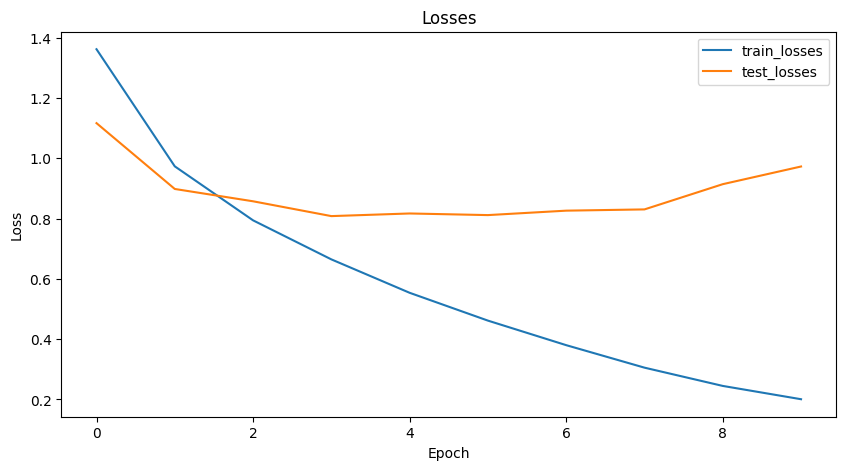

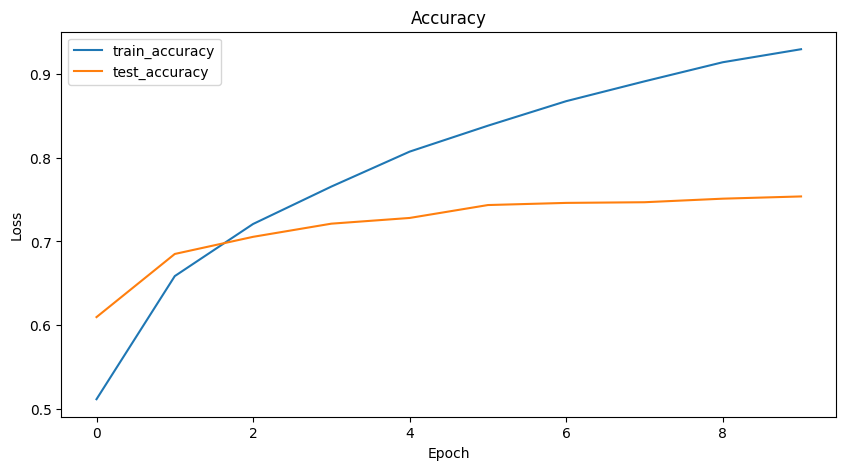

In [64]:
# Визуализация графиков loss/accuracy.

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="train_losses")
plt.plot(test_losses, label="test_losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label="train_accuracy")
plt.plot(test_accuracy, label="test_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Accuracy")
plt.legend()
plt.show()

Обучение с аугментацией

In [58]:
model = resnet18(pretrained=False, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [59]:
train_losses = []
test_losses = []
train_accuracy = []
test_accuracy = []

for epoch in range(epoches):
  start_time = time.time()
  test_loss = 0.0
  train_loss = 0.0
  train_acc = 0.0
  test_acc = 0.0
  for i, data in enumerate(train_loader_with_aug, 0):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    train_acc += accuracy(outputs, labels)

  end_time = time.time()
  with torch.no_grad():
    for data, labels in test_loader:
      outputs = model(data.to(device))
      loss = criterion(outputs, labels.to(device))
      test_loss += loss.item()
      test_acc += accuracy(outputs, labels.to(device))

  train_losses.append(train_loss/len(train_loader_with_aug))
  train_accuracy.append(train_acc/len(train_loader_with_aug))
  test_losses.append(test_loss/len(test_loader))
  test_accuracy.append(test_acc/len(test_loader))

  print(f"Epoch: {epoch+1}/{epoches}\ttrain_loss: {train_losses[-1]:.4f}\ttrain_accuracy: {train_accuracy[-1]:.4f}" \
    f"\ttest_loss: {test_losses[-1]:.4f}\ttest_accuracy: {test_accuracy[-1]:.4f}\ttime: {end_time-start_time:.2f}")
acc_with_aug = test_accuracy[-1]

Epoch: 1/10	train_loss: 1.5965	train_accuracy: 0.4198	test_loss: 1.2748	test_accuracy: 0.5382	time: 27.30
Epoch: 2/10	train_loss: 1.2929	train_accuracy: 0.5366	test_loss: 1.1015	test_accuracy: 0.6134	time: 27.29
Epoch: 3/10	train_loss: 1.1406	train_accuracy: 0.5945	test_loss: 1.0262	test_accuracy: 0.6363	time: 28.02
Epoch: 4/10	train_loss: 1.0455	train_accuracy: 0.6305	test_loss: 0.9291	test_accuracy: 0.6727	time: 27.48
Epoch: 5/10	train_loss: 0.9677	train_accuracy: 0.6596	test_loss: 0.8674	test_accuracy: 0.6961	time: 27.79
Epoch: 6/10	train_loss: 0.9091	train_accuracy: 0.6817	test_loss: 0.8434	test_accuracy: 0.7067	time: 29.11
Epoch: 7/10	train_loss: 0.8592	train_accuracy: 0.6973	test_loss: 0.7966	test_accuracy: 0.7220	time: 27.40
Epoch: 8/10	train_loss: 0.8273	train_accuracy: 0.7105	test_loss: 0.7843	test_accuracy: 0.7289	time: 27.53
Epoch: 9/10	train_loss: 0.7929	train_accuracy: 0.7230	test_loss: 0.7646	test_accuracy: 0.7374	time: 27.59
Epoch: 10/10	train_loss: 0.7588	train_accuracy

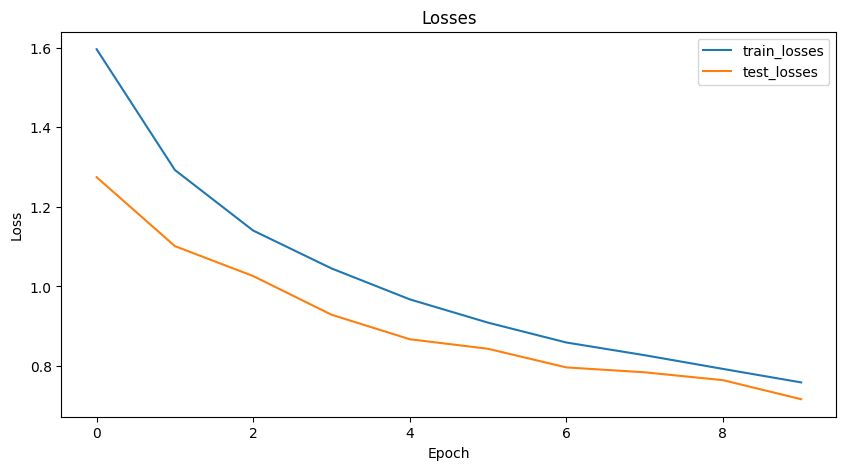

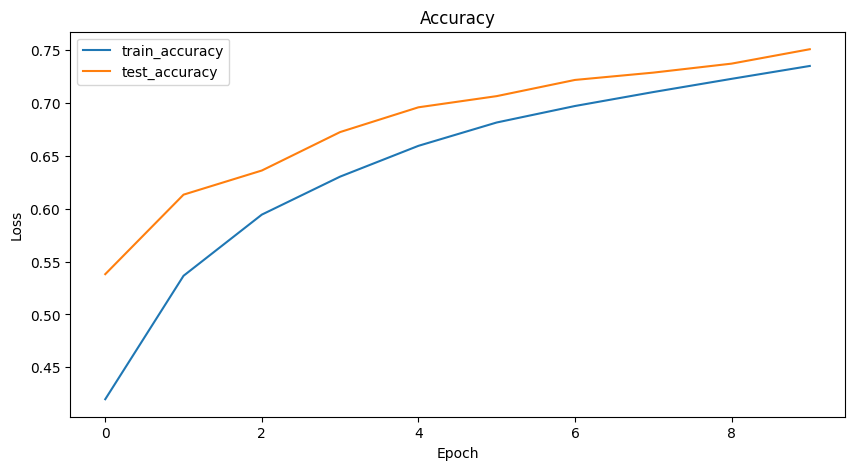

In [60]:
# Визуализация графиков loss/accuracy.

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="train_losses")
plt.plot(test_losses, label="test_losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label="train_accuracy")
plt.plot(test_accuracy, label="test_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Accuracy")
plt.legend()
plt.show()

#Результаты

In [65]:
print(f"Точность при обучении без аугментации:\t{acc_with_no_aug}")
print(f"Точность при обучении c аугментацией:\t{acc_with_aug}")

Точность при обучении без аугментации:	0.7537579113924051
Точность при обучении c аугментацией:	0.7510878164556962
